<a href="https://colab.research.google.com/github/prasadLgit/Machine-Learning/blob/main/random_linear_classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

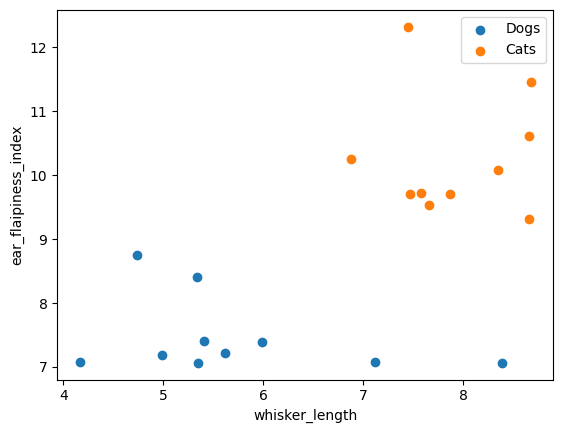

In [2]:
import matplotlib.pyplot as plt
import numpy as np

dog_whisker_length = np.random.normal(loc=5, scale=1, size=10)
dog_ear_flapiness_index = np.random.normal(loc=8, scale=1, size=10)

cat_whisker_length = np.random.normal(loc=8, scale=1, size=10)
cat_ear_flapiness_index = np.random.normal(loc=10, scale=1, size=10)

plt.scatter(dog_whisker_length, dog_ear_flapiness_index, label='Dogs')
plt.scatter(cat_whisker_length, cat_ear_flapiness_index, label='Cats')
plt.xlabel('whisker_length')
plt.ylabel('ear_flaipiness_index')
plt.legend()
plt.show()

In [12]:
import matplotlib.pyplot as plt
import numpy as np

# Data
dog_whisker_length = np.random.normal(loc=5, scale=1, size=10)
dog_ear_flapiness_index = np.random.normal(loc=8, scale=1, size=10)

cat_whisker_length = np.random.normal(loc=8, scale=1, size=10)
cat_ear_flapiness_index = np.random.normal(loc=5, scale=1, size=10)

dogs_data = np.vstack((dog_whisker_length, dog_ear_flapiness_index)).T
cats_data = np.vstack((cat_whisker_length, cat_ear_flapiness_index)).T

print(dogs_data)
print(cats_data)

def random_linear_classifier(dogs_data, cats_data, k, d):
    best_theta = None
    best_theta_0 = None
    best_error = np.inf

    for _ in range(k):
        theta_0 = np.random.uniform(-1, 1)
        theta = np.random.uniform(-1, 1, size=d)
        error = compute_error(dogs_data, cats_data, theta, theta_0)

        if error < best_error:
            best_theta = theta
            best_theta_0 = theta_0
            best_error = error

    return best_theta, best_theta_0, best_error

def compute_error(data_dogs, data_cats, theta, theta_0):
    error = 0
    for dog in data_dogs:
        if np.dot(theta, dog) + theta_0 <= 0:
           error += 1
    for cat in data_cats:
        if np.dot(theta, cat) + theta_0 >= 0:
           error += 1
    return error

[[4.67154922 9.26511613]
 [4.01894121 8.22204129]
 [3.63351869 8.47123562]
 [4.51721519 8.14800912]
 [2.86465241 6.73180357]
 [5.50624673 9.08461968]
 [7.20174194 8.69047153]
 [4.72693367 9.36146472]
 [4.00193488 7.92744328]
 [5.26340813 8.87017554]]
[[9.00520259 5.51690543]
 [8.40158244 4.76624394]
 [7.80832504 5.65880514]
 [8.69169533 4.33374559]
 [8.39471959 4.71315733]
 [7.27292165 3.92449959]
 [6.61516131 5.05526121]
 [6.81586072 3.8140132 ]
 [6.12791143 5.99556132]
 [7.41864989 4.84500621]]


In [13]:
best_theta, best_theta_0, best_error = random_linear_classifier(dogs_data, cats_data, 1000, 2)
print(best_theta, best_theta_0, best_error)

[-0.78298608  0.68209352] 0.3917775337127045 0


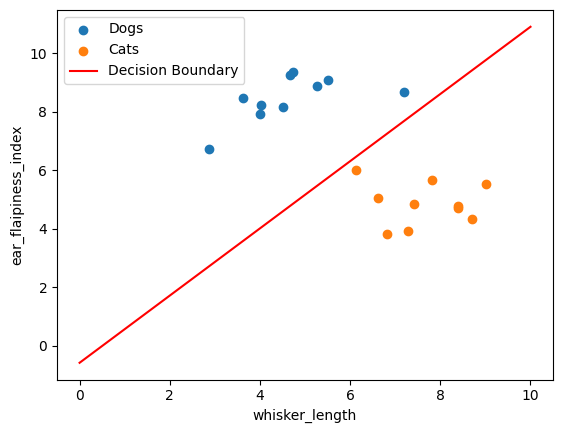

In [16]:
x = np.linspace(0, 10, 100)
y = -(best_theta[0] * x + best_theta_0) / best_theta[1]

plt.scatter(dog_whisker_length, dog_ear_flapiness_index, label='Dogs')
plt.scatter(cat_whisker_length, cat_ear_flapiness_index, label='Cats')
plt.plot(x, y, color='red', label='Decision Boundary')
plt.xlabel('whisker_length')
plt.ylabel('ear_flaipiness_index')
plt.legend()
plt.show()